In [1]:
import os
import random
import tensorflow as tf
from pathlib import Path
from scipy.io import loadmat
from scipy.signal import resample_poly
from sklearn.metrics import f1_score, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import hamming_loss

In [2]:
SEED = 42
EPOCHS = 250

file = open("../../datasets/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt")
lines = file.readlines()

processedList = []

for i, line in enumerate(lines):
    try:
        line = line.split(",")
        last = line[5].split(";")[0]
        last = last.strip()
        if last == "":
            break
        temp = [line[0], line[1], line[2], line[3], line[4], last]
        processedList.append(temp)
    except Exception:
        print("Error at line number: ", i)


os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

Error at line number:  281873
Error at line number:  281874
Error at line number:  281875


In [3]:
processedList[:100]

[['33', 'Jogging', '49105962326000', '-0.6946377', '12.680544', '0.50395286'],
 ['33', 'Jogging', '49106062271000', '5.012288', '11.264028', '0.95342433'],
 ['33', 'Jogging', '49106112167000', '4.903325', '10.882658', '-0.08172209'],
 ['33', 'Jogging', '49106222305000', '-0.61291564', '18.496431', '3.0237172'],
 ['33', 'Jogging', '49106332290000', '-1.1849703', '12.108489', '7.205164'],
 ['33', 'Jogging', '49106442306000', '1.3756552', '-2.4925237', '-6.510526'],
 ['33', 'Jogging', '49106542312000', '-0.61291564', '10.56939', '5.706926'],
 ['33', 'Jogging', '49106652389000', '-0.50395286', '13.947236', '7.0553403'],
 ['33', 'Jogging', '49106762313000', '-8.430995', '11.413852', '5.134871'],
 ['33', 'Jogging', '49106872299000', '0.95342433', '1.3756552', '1.6480621'],
 ['33', 'Jogging', '49106982315000', '-8.19945', '19.57244', '2.7240696'],
 ['33', 'Jogging', '49107092330000', '1.4165162', '5.7886477', '2.982856'],
 ['33', 'Jogging', '49107202316000', '-1.879608', '-2.982856', '-0.2996

In [4]:
columns = ["user", "activity", "time", "x", "y", "z"]
data = pd.DataFrame(data=processedList, columns=columns)
data.head()

,user,activity,time,x,y,z
0,33,Jogging,49105962326000,-0.6946377,12.680544,0.50395286
1,33,Jogging,49106062271000,5.012288,11.264028,0.95342433
2,33,Jogging,49106112167000,4.903325,10.882658,-0.08172209
3,33,Jogging,49106222305000,-0.61291564,18.496431,3.0237172
4,33,Jogging,49106332290000,-1.1849703,12.108489,7.205164


In [5]:
data.shape

(343416, 6)

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 343416 entries, 0 to 343415
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   user      343416 non-null  str  
 1   activity  343416 non-null  str  
 2   time      343416 non-null  str  
 3   x         343416 non-null  str  
 4   y         343416 non-null  str  
 5   z         343416 non-null  str  
dtypes: str(6)
memory usage: 15.7 MB


In [7]:
data.isnull().sum()

user        0
activity    0
time        0
x           0
y           0
z           0
dtype: int64

In [8]:
data["x"] = data["x"].astype("float")
data["y"] = data["y"].astype("float")
data["z"] = data["z"].astype("float")

In [9]:
Fs = 20
activities = data["activity"].value_counts().index
activities

Index(['Walking', 'Jogging', 'Upstairs', 'Downstairs', 'Sitting', 'Standing'], dtype='str', name='activity')

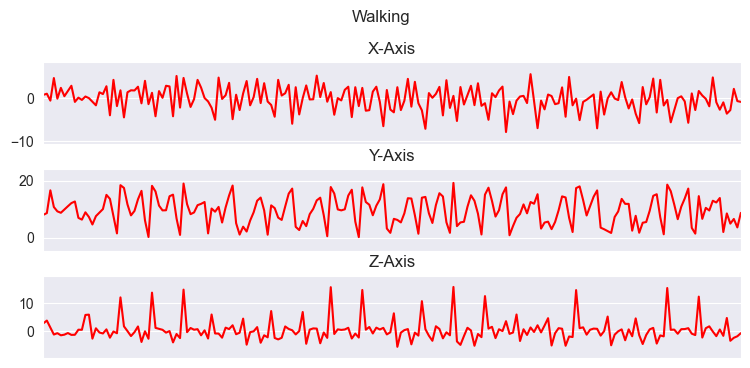

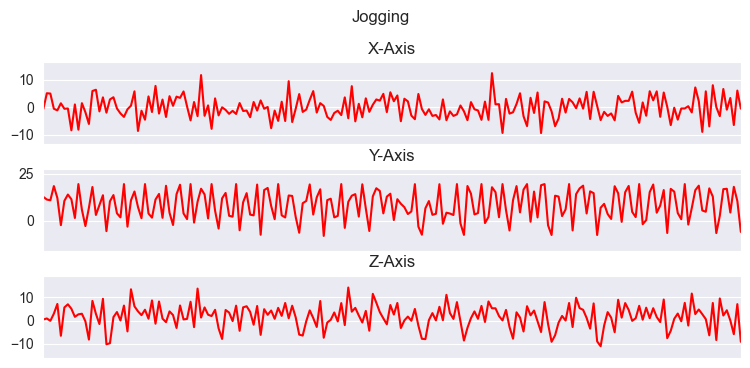

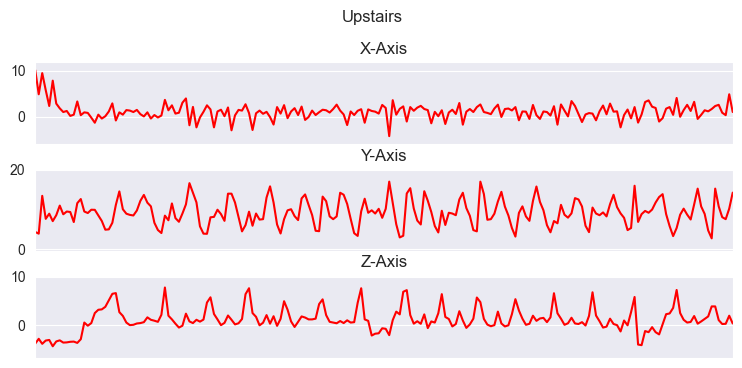

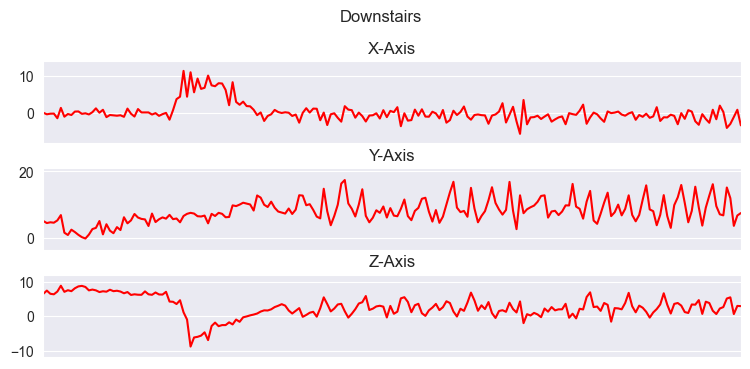

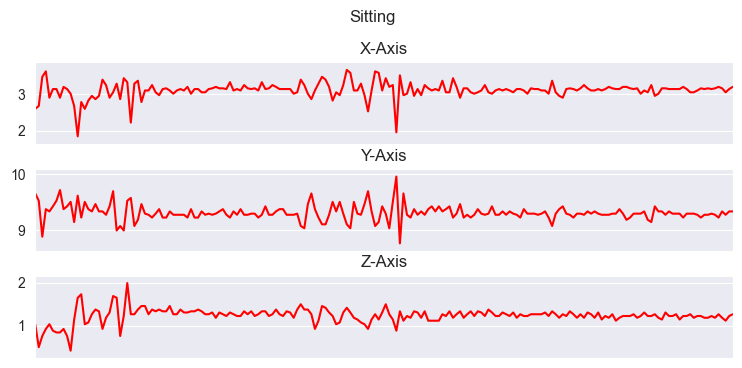

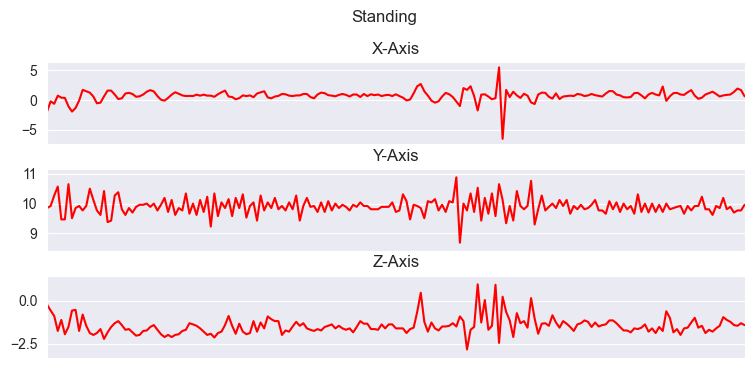

In [10]:
def plot_activity(activity, data):
    fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(9, 4), sharex=True)
    plot_axis(ax0, data["time"], data["x"], "X-Axis")
    plot_axis(ax1, data["time"], data["y"], "Y-Axis")
    plot_axis(ax2, data["time"], data["z"], "Z-Axis")
    plt.subplots_adjust(hspace=0.3)
    fig.suptitle(activity)
    plt.subplots_adjust(top=0.85)
    plt.show()


def plot_axis(ax, x, y, title):
    ax.plot(x, y, "r")
    ax.set_title(title)
    ax.xaxis.set_visible(False)
    ax.set_ylim([min(y) - np.std(y), max(y) + np.std(y)])
    ax.set_xlim([min(x), max(x)])
    ax.grid(True)


for activity in activities:
    data_for_plot = data[(data["activity"] == activity)][: Fs * 10]
    plot_activity(activity, data_for_plot)

In [11]:
df = data.drop(["user", "time"], axis=1).copy()
df.head()

,activity,x,y,z
0,Jogging,-0.694638,12.680544,0.503953
1,Jogging,5.012288,11.264028,0.953424
2,Jogging,4.903325,10.882658,-0.081722
3,Jogging,-0.612916,18.496431,3.023717
4,Jogging,-1.184970,12.108489,7.205164


In [12]:
df["activity"].value_counts()

activity
Walking       137375
Jogging       129392
Upstairs       35137
Downstairs     33358
Sitting         4599
Standing        3555
Name: count, dtype: int64

In [13]:
Walking = df[df["activity"] == "Walking"].head(3555).copy()
Jogging = df[df["activity"] == "Jogging"].head(3555).copy()
Upstairs = df[df["activity"] == "Upstairs"].head(3555).copy()
Downstairs = df[df["activity"] == "Downstairs"].head(3555).copy()
Sitting = df[df["activity"] == "Sitting"].head(3555).copy()
Standing = df[df["activity"] == "Standing"].copy()

balanced_data = pd.concat(
    [Walking, Jogging, Upstairs, Downstairs, Sitting, Standing],
    ignore_index=True,
)
balanced_data.shape

(21330, 4)

In [14]:
balanced_data["activity"].value_counts()

activity
Walking       3555
Jogging       3555
Upstairs      3555
Downstairs    3555
Sitting       3555
Standing      3555
Name: count, dtype: int64

In [15]:
balanced_data.head()

,activity,x,y,z
0,Walking,0.844462,8.008764,2.792171
1,Walking,1.116869,8.621680,3.786457
2,Walking,-0.503953,16.657684,1.307553
3,Walking,4.794363,10.760075,-1.184970
4,Walking,-0.040861,9.234595,-0.694638


In [16]:
label = LabelEncoder()
balanced_data["label"] = label.fit_transform(balanced_data["activity"])
balanced_data.head()

,activity,x,y,z,label
0,Walking,0.844462,8.008764,2.792171,5
1,Walking,1.116869,8.621680,3.786457,5
2,Walking,-0.503953,16.657684,1.307553,5
3,Walking,4.794363,10.760075,-1.184970,5
4,Walking,-0.040861,9.234595,-0.694638,5


In [17]:
label.classes_

array(['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs',
       'Walking'], dtype=object)

In [18]:
X = balanced_data[["x", "y", "z"]]
y = balanced_data["label"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

scaled_X = pd.DataFrame(data=X, columns=["x", "y", "z"])
scaled_X["label"] = y.values

scaled_X.head()

,x,y,z,label
0,0.000503,-0.099190,0.337933,5
1,0.073590,0.020386,0.633446,5
2,-0.361275,1.588160,-0.103312,5
3,1.060258,0.437573,-0.844119,5
4,-0.237028,0.139962,-0.698386,5


In [19]:
Fs = 20
frame_size = Fs * 4  # 80
hop_size = Fs * 2  # 40


def get_frames(df, frame_size, hop_size):
    frames = []
    labels = []

    for i in range(0, len(df) - frame_size + 1, hop_size):
        frame = np.column_stack(
            (
                df["x"].values[i : i + frame_size],
                df["y"].values[i : i + frame_size],
                df["z"].values[i : i + frame_size],
            )
        )

        frame_label = stats.mode(
            df["label"].values[i : i + frame_size],
            keepdims=True,
        ).mode[0]

        frames.append(frame)
        labels.append(frame_label)

    return np.asarray(frames), np.asarray(labels)


X, y = get_frames(scaled_X, frame_size, hop_size)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

In [20]:
X_train = X_train.reshape(-1, frame_size, 3, 1)
X_test = X_test.reshape(-1, frame_size, 3, 1)

In [21]:
X_train[0].shape, X_test[0].shape

((80, 3, 1), (80, 3, 1))

In [22]:
wisdm_class_to_id = {class_name: class_id for class_id, class_name in enumerate(label.classes_)}

wisdm_class_to_id

{'Downstairs': 0,
 'Jogging': 1,
 'Sitting': 2,
 'Standing': 3,
 'Upstairs': 4,
 'Walking': 5}

In [23]:
UNIMIB_ACTIVITY_NAMES = [
    "StandingUpFS",
    "StandingUpFL",
    "Walking",
    "Running",
    "GoingUpS",
    "Jumping",
    "GoingDownS",
    "LyingDownFS",
    "SittingDown",
    "FallingForw",
    "FallingRight",
    "FallingBack",
    "HittingObstacle",
    "FallingWithPS",
    "FallingBackSC",
    "Syncope",
    "FallingLeft",
]

UNIMIB_TO_WISDM = {
    "Walking": "Walking",
    "Running": "Jogging",
    "GoingUpS": "Upstairs",
    "GoingDownS": "Downstairs",
}

In [24]:
def reshape_unimib_signals(acc_data):
    acc_data = np.asarray(acc_data)

    if acc_data.ndim == 3:
        if acc_data.shape[1:] == (151, 3):
            return acc_data

        if acc_data.shape[1:] == (3, 151):
            return np.transpose(acc_data, (0, 2, 1))

    if acc_data.ndim == 2 and acc_data.shape[1] == 453:
        x = acc_data[:, :151]
        y = acc_data[:, 151:302]
        z = acc_data[:, 302:453]

        return np.stack((x, y, z), axis=-1)

    raise ValueError(f"Unsupported UniMiB signal shape: {acc_data.shape}")

In [ ]:
def prepare_unimib(
    acc_data,
    acc_labels,
    wisdm_class_to_id,
    target_length=80,
):
    signals = reshape_unimib_signals(acc_data)
    labels = np.asarray(acc_labels)

    if labels.ndim == 1:
        activity_ids = labels.astype(int)
    else:
        activity_ids = labels[:, 0].astype(int)

    resampled_signals = []
    selected_labels = []
    selected_original_labels = []

    for signal, activity_id in zip(signals, activity_ids):
        activity_name = UNIMIB_ACTIVITY_NAMES[activity_id - 1]

        if activity_name not in UNIMIB_TO_WISDM:
            continue

        wisdm_name = UNIMIB_TO_WISDM[activity_name]

        resampled_signal = resample_poly(
            signal,
            up=target_length,
            down=signal.shape[0],
            axis=0,
            padtype="line",
        )

        resampled_signals.append(resampled_signal)
        selected_labels.append(wisdm_class_to_id[wisdm_name])
        selected_original_labels.append(activity_name)

    X_unimib = np.asarray(resampled_signals, dtype=np.float32)
    y_unimib = np.asarray(selected_labels, dtype=np.int64)

    unimib_scaler = StandardScaler()

    original_shape = X_unimib.shape

    X_unimib = unimib_scaler.fit_transform(
        X_unimib.reshape(-1, 3)
    )

    X_unimib = X_unimib.reshape(original_shape)
    X_unimib = X_unimib[..., np.newaxis]

    return (
        X_unimib,
        y_unimib,
        np.asarray(selected_original_labels),
    )


def calculate_label_statistics(X, y, class_names):
    signals = X[..., 0] if X.ndim == 4 else X
    rows = []

    for class_id in np.unique(y):
        class_signals = signals[y == class_id]
        flattened = class_signals.reshape(-1, 3)

        rows.append(
            {
                "label": class_names[class_id],
                "samples": len(class_signals),
                "x_mean": flattened[:, 0].mean(),
                "x_std": flattened[:, 0].std(),
                "y_mean": flattened[:, 1].mean(),
                "y_std": flattened[:, 1].std(),
                "z_mean": flattened[:, 2].mean(),
                "z_std": flattened[:, 2].std(),
            }
        )

    return pd.DataFrame(rows)

In [26]:
acc_data_path = Path("../../datasets/UniMiB-SHAR/data/acc_data.mat")
acc_labels_path = Path("../../datasets/UniMiB-SHAR/data/acc_labels.mat")

acc_data_mat = loadmat(acc_data_path)
acc_labels_mat = loadmat(acc_labels_path)

In [39]:
acc_data = acc_data_mat["acc_data"]
acc_labels = acc_labels_mat["acc_labels"]

unimib_signals = reshape_unimib_signals(acc_data)

X_unimib, y_unimib, unimib_original_labels = prepare_unimib(
    acc_data,
    acc_labels,
    wisdm_class_to_id,
)

unimib_statistics = calculate_label_statistics(
    X_unimib,
    y_unimib,
    label.classes_,
)



In [40]:
wisdm_train_statistics = calculate_label_statistics(
    X_train,
    y_train,
    label.classes_,
)

wisdm_test_statistics = calculate_label_statistics(
    X_test,
    y_test,
    label.classes_,
)


In [29]:
shared_class_names = [
    "Downstairs",
    "Jogging",
    "Upstairs",
    "Walking",
]

wisdm_shared_statistics = wisdm_train_statistics[
    wisdm_train_statistics["label"].isin(shared_class_names)
].copy()

unimib_shared_statistics = unimib_statistics[
    unimib_statistics["label"].isin(shared_class_names)
].copy()

statistics_comparison = wisdm_shared_statistics.merge(
    unimib_shared_statistics,
    on="label",
    suffixes=("_wisdm", "_unimib"),
)

comparison_columns = [
    "label",
    "x_mean_wisdm",
    "x_mean_unimib",
    "x_std_wisdm",
    "x_std_unimib",
    "y_mean_wisdm",
    "y_mean_unimib",
    "y_std_wisdm",
    "y_std_unimib",
    "z_mean_wisdm",
    "z_mean_unimib",
    "z_std_wisdm",
    "z_std_unimib",
]

display(
    statistics_comparison[comparison_columns].round(3)
)
for axis in ["x", "y", "z"]:
    statistics_comparison[f"{axis}_mean_difference"] = (
        statistics_comparison[f"{axis}_mean_unimib"]
        - statistics_comparison[f"{axis}_mean_wisdm"]
    ).abs()

    statistics_comparison[f"{axis}_std_ratio"] = (
        statistics_comparison[f"{axis}_std_unimib"]
        / statistics_comparison[f"{axis}_std_wisdm"]
    )

display(
    statistics_comparison[
        [
            "label",
            "x_mean_difference",
            "x_std_ratio",
            "y_mean_difference",
            "y_std_ratio",
            "z_mean_difference",
            "z_std_ratio",
        ]
    ].round(3)
)

,label,x_mean_wisdm,x_mean_unimib,x_std_wisdm,x_std_unimib,y_mean_wisdm,y_mean_unimib,y_std_wisdm,y_std_unimib,z_mean_wisdm,z_mean_unimib,z_std_wisdm,z_std_unimib
0,Downstairs,0.119,-0.022,0.882,0.981,0.090,0.091,0.752,0.946,0.070,-0.061,0.756,0.927
1,Jogging,0.351,-0.040,1.654,1.146,0.177,0.072,1.530,1.065,-0.231,0.055,1.323,1.119
2,Upstairs,-0.154,0.039,0.601,0.975,0.084,-0.005,0.729,0.939,0.225,-0.089,0.802,1.029
3,Walking,0.233,0.040,0.769,0.838,0.227,-0.170,0.765,0.963,-0.483,0.034,0.922,0.901


,label,x_mean_difference,x_std_ratio,y_mean_difference,y_std_ratio,z_mean_difference,z_std_ratio
0,Downstairs,0.141,1.112,0.001,1.258,0.131,1.225
1,Jogging,0.390,0.693,0.105,0.696,0.287,0.846
2,Upstairs,0.192,1.622,0.089,1.288,0.314,1.283
3,Walking,0.193,1.090,0.397,1.258,0.517,0.977


In [30]:
tf.keras.backend.clear_session()
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

model = Sequential()
model.add(Conv2D(32, (2, 2), activation="relu", input_shape=X_train[0].shape))
model.add(Dropout(0.1))

model.add(Conv2D(64, (2, 2), activation="relu"))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(6, activation="softmax"))

C:\Users\amanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(
    optimizer=Adam(learning_rate=0.003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    verbose=1,
)
weights_directory = Path("saved_model")
weights_directory.mkdir(parents=True, exist_ok=True)

weights_path = weights_directory / (
    f"wisdm_cnn_seed_{SEED}_epochs_{EPOCHS}.weights.h5"
)

model.save_weights(weights_path)

print(f"Model weights saved to: {weights_path}")

Epoch 1/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3435 - loss: 1.5059 - val_accuracy: 0.7290 - val_loss: 0.9155
Epoch 2/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7718 - loss: 0.6164 - val_accuracy: 0.7944 - val_loss: 0.4133
Epoch 3/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8800 - loss: 0.3101 - val_accuracy: 0.8598 - val_loss: 0.2964
Epoch 4/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9106 - loss: 0.2503 - val_accuracy: 0.8879 - val_loss: 0.2610
Epoch 5/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9435 - loss: 0.1541 - val_accuracy: 0.9065 - val_loss: 0.2571
Epoch 6/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9553 - loss: 0.1351 - val_accuracy: 0.8879 - val_loss: 0.2840
Epoch 7/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9741 - loss: 0.0903 - val_accuracy: 0.9159 - val_loss: 0.2044
Epoch 8/250
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9882 - loss: 0.0529 - val_accuracy: 0.

In [32]:
unimib_probabilities = model.predict(X_unimib)
y_unimib_pred = np.argmax(unimib_probabilities, axis=1)

prediction_counts = pd.Series(label.inverse_transform(y_unimib_pred)).value_counts()

print(prediction_counts)

print(prediction_counts.div(len(y_unimib_pred)).mul(100).round(2))
results = pd.DataFrame(
    {
        "true": label.inverse_transform(y_unimib),
        "predicted": label.inverse_transform(y_unimib_pred),
    }
)

print(
    pd.crosstab(
        results["true"],
        results["predicted"],
        margins=True,
    )
)
shared_class_names = [
    "Downstairs",
    "Jogging",
    "Upstairs",
    "Walking",
]

shared_class_ids = [wisdm_class_to_id[class_name] for class_name in shared_class_names]

print(
    "Accuracy:",
    accuracy_score(y_unimib, y_unimib_pred),
)

print(
    "Macro F1:",
    f1_score(
        y_unimib,
        y_unimib_pred,
        labels=shared_class_ids,
        average="macro",
        zero_division=0,
    ),
)

print(
    classification_report(
        y_unimib,
        y_unimib_pred,
        labels=shared_class_ids,
        target_names=shared_class_names,
        zero_division=0,
    )
)

187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Upstairs      2085
Downstairs    1638
Sitting       1119
Standing       764
Walking        355
Jogging          7
Name: count, dtype: int64
Upstairs      34.94
Downstairs    27.45
Sitting       18.75
Standing      12.80
Walking        5.95
Jogging        0.12
Name: count, dtype: float64
predicted   Downstairs  Jogging  Sitting  Standing  Upstairs  Walking   All
true                                                                       
Downstairs         304        0      247       214       462       97  1324
Jogging            544        6      318       126       859      132  1985
Upstairs           228        1      163       179       264       86   921
Walking            562        0      391       245       500       40  1738
All               1638        7     1119       764      2085      355  5968
Accuracy: 0.10288203753351206
Macro F1: 0.10629053939498702
              precision    recall  f1-score   support

  Downstairs       0.19 

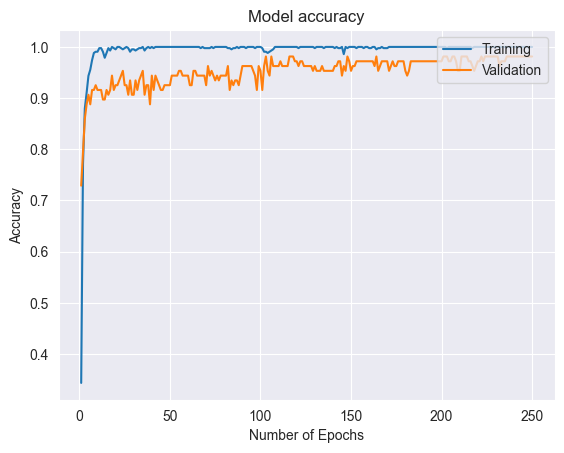

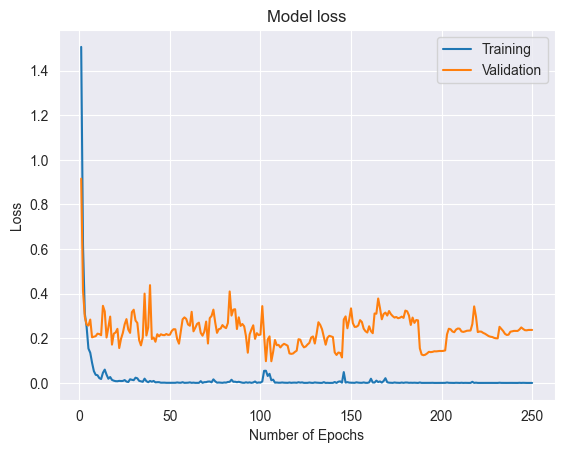

In [33]:
def plot_learningCurve(history, epochs):

    epoch_range = range(1, epochs + 1)
    plt.plot(epoch_range, history.history["accuracy"])
    plt.plot(epoch_range, history.history["val_accuracy"])
    plt.title("Model accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Number of Epochs")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()

    # Plotting the loss graph of training & validation
    plt.plot(epoch_range, history.history["loss"])
    plt.plot(epoch_range, history.history["val_loss"])
    plt.title("Model loss")
    plt.ylabel("Loss")
    plt.xlabel("Number of Epochs")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()


plot_learningCurve(history, EPOCHS)

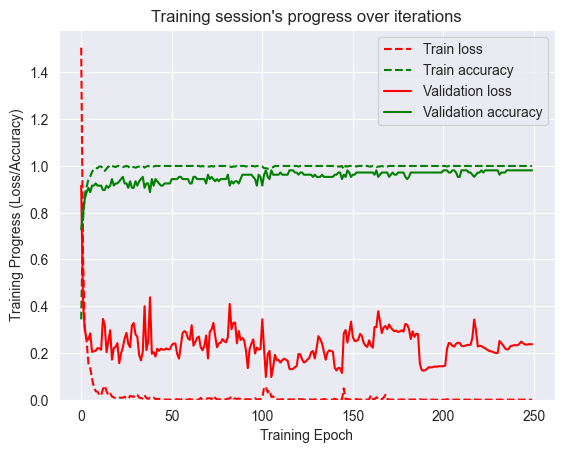

In [34]:
plt.plot(np.array(history.history["loss"]), "r--", label="Train loss")
plt.plot(np.array(history.history["accuracy"]), "g--", label="Train accuracy")
plt.plot(np.array(history.history["val_loss"]), "r-", label="Validation loss")
plt.plot(
    np.array(history.history["val_accuracy"]),
    "g-",
    label="Validation accuracy",
)
plt.title("Training session's progress over iterations")
plt.legend(loc="upper right")
plt.ylabel("Training Progress (Loss/Accuracy)")
plt.xlabel("Training Epoch")
plt.ylim(0)
plt.show()

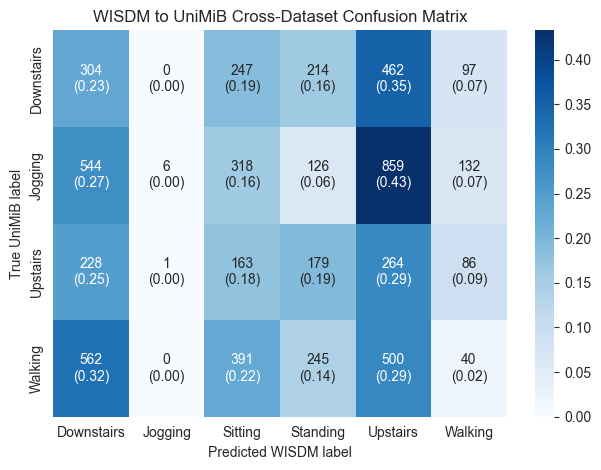

In [35]:
all_class_names = list(label.classes_)
all_class_ids = np.arange(len(all_class_names))

shared_class_names = [
    "Downstairs",
    "Jogging",
    "Upstairs",
    "Walking",
]

shared_class_ids = [
    wisdm_class_to_id[class_name]
    for class_name in shared_class_names
]

full_matrix = confusion_matrix(
    y_unimib,
    y_unimib_pred,
    labels=all_class_ids,
)

cross_dataset_matrix = full_matrix[shared_class_ids, :]

normalized_matrix = cross_dataset_matrix / cross_dataset_matrix.sum(
    axis=1,
    keepdims=True,
)

annotations = np.empty_like(cross_dataset_matrix, dtype=object)

for row in range(cross_dataset_matrix.shape[0]):
    for column in range(cross_dataset_matrix.shape[1]):
        annotations[row, column] = (
            f"{cross_dataset_matrix[row, column]}\n"
            f"({normalized_matrix[row, column]:.2f})"
        )



sns.heatmap(
    normalized_matrix,
    annot=annotations,
    fmt="",
    xticklabels=all_class_names,
    yticklabels=shared_class_names,
    cmap="Blues",
)

plt.xlabel("Predicted WISDM label")
plt.ylabel("True UniMiB label")
plt.title("WISDM to UniMiB Cross-Dataset Confusion Matrix")
plt.tight_layout()
plt.show()

In [36]:
y_pred = np.argmax(model.predict(X_test), axis=-1)
print("Precision Score : ", precision_score(y_test, y_pred, average=None))
print("Recall Score : ", recall_score(y_test, y_pred, average=None))
print("Accuracy Score :", accuracy_score(y_test, y_pred, normalize=True))
print("Loss Score :", hamming_loss(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Precision Score :  [1.         1.         0.94736842 0.94736842 1.         1.        ]
Recall Score :  [1.         1.         1.         1.         0.94444444 0.94117647]
Accuracy Score : 0.9813084112149533
Loss Score : 0.018691588785046728


In [37]:
def plot_dataset_comparison(
    X_wisdm,
    y_wisdm,
    X_unimib,
    y_unimib,
    label_encoder,
    shared_classes,
):
    fig, axes = plt.subplots(
        len(shared_classes),
        3,
        figsize=(15, 3.5 * len(shared_classes)),
        sharex=True,
    )

    for row, activity in enumerate(shared_classes):
        class_id = np.where(label_encoder.classes_ == activity)[0][0]

        wisdm_mean = X_wisdm[y_wisdm == class_id].mean(axis=0)[:, :, 0]
        unimib_mean = X_unimib[y_unimib == class_id].mean(axis=0)[:, :, 0]

        for axis in range(3):
            ax = axes[row, axis]

            ax.plot(
                wisdm_mean[:, axis],
                label="WISDM",
                linewidth=2,
            )

            ax.plot(
                unimib_mean[:, axis],
                label="UniMiB",
                linewidth=2,
            )

            ax.set_title(
                f"{activity} - {'XYZ'[axis]}"
            )

            ax.grid(True)

            if row == 0 and axis == 0:
                ax.legend()

    plt.tight_layout()

,label,samples_wisdm,x_mean_wisdm,x_std_wisdm,y_mean_wisdm,y_std_wisdm,z_mean_wisdm,z_std_wisdm,samples_unimib,x_mean_unimib,...,y_mean_unimib,y_std_unimib,z_mean_unimib,z_std_unimib,x_mean_difference,x_std_ratio,y_mean_difference,y_std_ratio,z_mean_difference,z_std_ratio
0,Downstairs,71,0.119,0.882,0.090,0.752,0.070,0.756,1324,-0.022,...,0.091,0.946,-0.061,0.927,0.141,1.112,0.001,1.258,0.131,1.225
1,Jogging,71,0.351,1.654,0.177,1.530,-0.231,1.323,1985,-0.040,...,0.072,1.065,0.055,1.119,0.390,0.693,0.105,0.696,0.287,0.846
2,Upstairs,71,-0.154,0.601,0.084,0.729,0.225,0.802,921,0.039,...,-0.005,0.939,-0.089,1.029,0.192,1.622,0.089,1.288,0.314,1.283
3,Walking,71,0.233,0.769,0.227,0.765,-0.483,0.922,1738,0.040,...,-0.170,0.963,0.034,0.901,0.193,1.090,0.397,1.258,0.517,0.977


        label  samples  x_mean  x_std  y_mean  y_std  z_mean  z_std
0  Downstairs       71   0.119  0.882   0.090  0.752   0.070  0.756
1     Jogging       71   0.351  1.654   0.177  1.530  -0.231  1.323
2     Sitting       71  -0.161  1.035  -0.679  1.090   0.596  0.988
3    Standing       70  -0.298  0.252   0.215  0.133  -0.228  0.586
4    Upstairs       71  -0.154  0.601   0.084  0.729   0.225  0.802
5     Walking       71   0.233  0.769   0.227  0.765  -0.483  0.922
        label  samples  x_mean  x_std  y_mean  y_std  z_mean  z_std
0  Downstairs     1324  -0.022  0.981   0.091  0.946  -0.061  0.927
1     Jogging     1985  -0.040  1.146   0.072  1.065   0.055  1.119
2    Upstairs      921   0.039  0.975  -0.005  0.939  -0.089  1.029
3     Walking     1738   0.040  0.838  -0.170  0.963   0.034  0.901


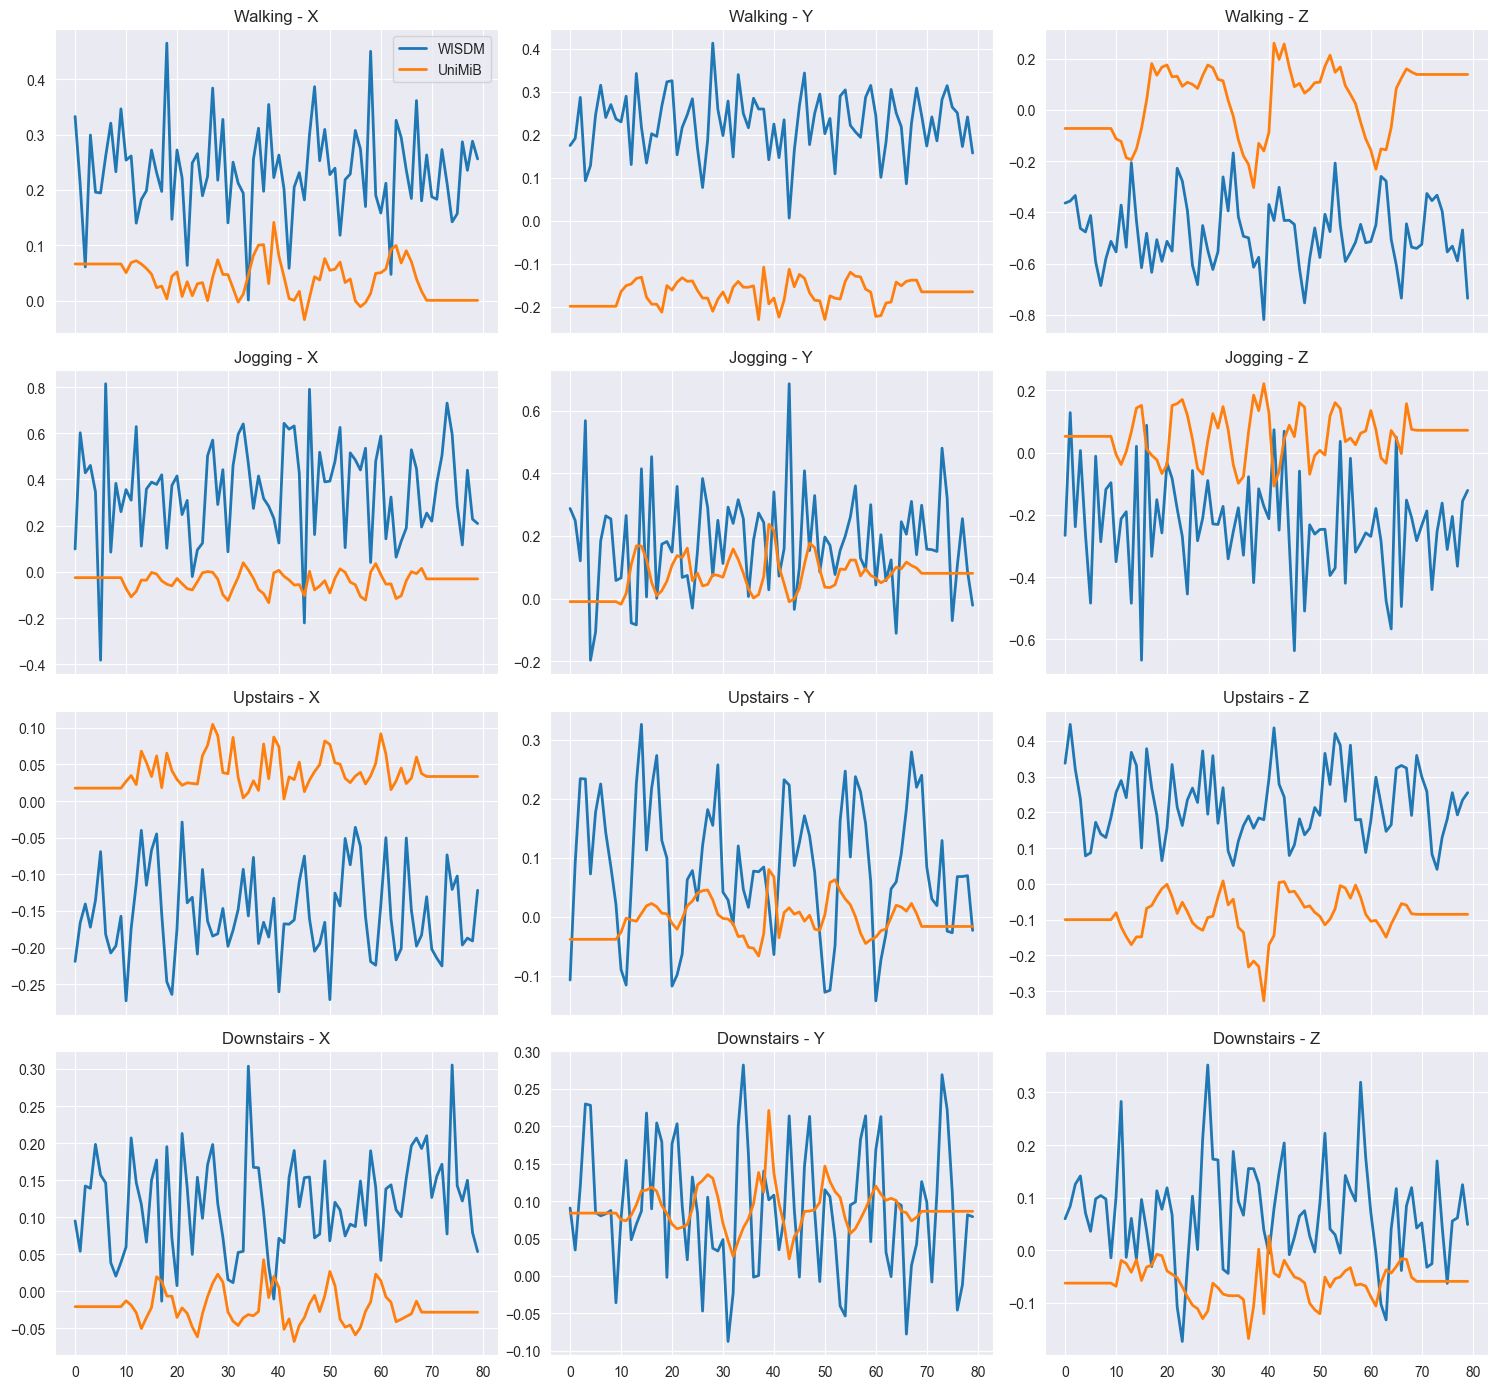

In [38]:
display(statistics_comparison.round(3))
print(wisdm_train_statistics.round(3))
print(unimib_statistics.round(3))
plot_dataset_comparison(
    X_train,
    y_train,
    X_unimib,
    y_unimib,
    label,
    [
        "Walking",
        "Jogging",
        "Upstairs",
        "Downstairs",
    ],
)
